# MPA-MLF, Lab 6 - Feedforward Neural Networks with regularization techniques and hyperparameter tunning

## Exercise 1 - Classification of an images 

The goal of this task will be to create Multi-layer perceptron model, that is able to recognize the  CIFAR10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). The CIFAR10 dataset consist of 60000 images with resolution of 32x32 pixels. There are 10 classes in total - *airplane*, *automobile*, *bird*, *cat*, *deer*, *dog*, *frog*, *horse*, *ship*, *truck*

These is an example of the dataset:

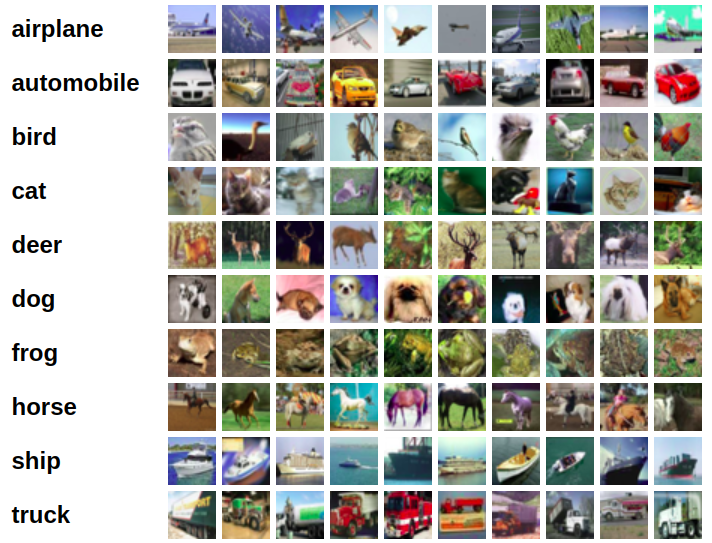

### 0. Import libraries

In [1]:
# Due to problems with TensorFlow's GPU implementation, I completely rewrote the cells to a single large functions.
# Mainly had to remove all TensorFlow imports and GPU stuff from the global scope because of GPU memory issues (TensorFlow would eventually use up all memory)
# All cells except this one and the last two now contain only function definitions and are used in the last two cells.

import os, glob, ctypes, sysconfig

# 1. Inject the Windows/WSL bridge
ctypes.CDLL("/usr/lib/wsl/lib/libcuda.so.1", mode=ctypes.RTLD_GLOBAL)

# 2. Inject all pip-installed NVIDIA libraries
for lib in glob.glob(os.path.join(sysconfig.get_path('purelib'), 'nvidia', '*', 'lib', '*.so*')):
    try: ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
    except: pass

import multiprocessing as mp
import pandas as pd
import time
import os
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Define the exact parameters we want to test
num_trials = 200
csv_filename = "results.csv"
best_acc = 0
best_params = None
epochs = 100



In [2]:
# from keras.models import Sequential
# from keras.layers import Dense, Flatten
# from keras.optimizers import SGD
# from keras.datasets import cifar10
# from keras.utils import to_categorical
# from keras import optimizers
# from keras import activations
# from keras.callbacks import EarlyStopping

font = {'weight' : 'bold',
        'size'   : 12}

matplotlib.rc('font', **font)

### 1. Load the Dataset
The dataset is already a part of the Keras library, so we can quickly load it using the following command

In [3]:
# The dataset is loaded and preprocessed in the second to last cell as part of each random search iteration due to problems mentioned above

The following numbered labels represent the labels in the dataset:

In [4]:
labels = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

### 2. Data Examination

Fistly, lets have a look and the couple of images we have,

In [5]:
# This function is not used due to not importing Tensorflow which would cause problems with GPU
def display_random_images(x_data: np.array, y_data: np.array, count: int = 10) -> None:
  index = np.array(len(x_data))
  selected_ind = np.random.choice(index, count)

  selected_img = x_data[selected_ind]
  selected_labels_encoded = y_data[selected_ind]
  selected_labels = [labels[x[0]] for x in selected_labels_encoded]

  concat_img = np.concatenate(selected_img, axis=1)

  plt.figure(figsize=(20,10))
  plt.imshow(concat_img)

  for id_label, label in enumerate(selected_labels):
    plt.text((32/2) + 32*id_label - len(label), 32*(5/4), label)
  plt.axis('off')
  plt.show()



In our dataset, we have 60000 images with 32x32 resolution. Each image has three channels (R, G, B). We have 50000 images for training and 10000 images for testing. Each channel for each image has values from 0 - 255, where each number represents the pixel intensity. 
With the combination of intensities of R, G and B, you can display up to 16,777,216 different colours (256^3)

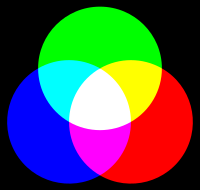

Here you can display each channel separately:

In [6]:
# This function is not used due to not importing Tensorflow which would cause problems with GPU
def display_channels_separately(image: np.array) -> None:

  plt.figure()
  fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(10, 5))


  axs[0].imshow(image[:,:,0],cmap='Reds')
  axs[1].imshow(image[:,:,1],cmap='Blues')
  axs[2].imshow(image[:,:,2],cmap='Greens')

  axs[3].imshow(image)

  plt.show()

### 3. Preprocessing of the images

For machine learning purposes, we have to preprocess our images. Firstly we need to scale our images, to scale intensity values from 0-1 (min-max scaling)

We need to one-hot-encode the labels in our ground truth variable as our second preprocessing.

### 4. Define the model architecture

In [7]:
def randomize_hyperparams() -> dict:
  optimizers = ['Adam']
  activations = ['relu', 'gelu', 'elu', 'tanh', 'selu']

  selected_optimizer = np.random.choice(optimizers)
  selected_learning_rate = np.pow(10, np.random.uniform(-4, -3))
  selected_hidden_layers = np.random.randint(1, 7)
  selected_epochs = epochs
  selected_dropout_rate = np.random.uniform(0.1, 0.3)
  selected_l2_reg = np.pow(10, np.random.uniform(-5, -3))
  selected_batch_size = int(np.pow(2, np.random.uniform(6, 9)))
  selected_hidden_units = []
  selected_activations = np.random.choice(activations)

  compression_factor = np.random.choice([0.5, 0.75, 1.0])
  current_neurons = int(np.pow(2, np.random.uniform(8, 12)))

  for _ in range(selected_hidden_layers):
    selected_hidden_units.append(int(current_neurons))
    current_neurons = max(64, current_neurons * compression_factor) # Update the number of neurons for the next layer


  return {
    'optimizer': selected_optimizer,
    'learning_rate': selected_learning_rate,
    'hidden_layers': selected_hidden_layers,
    'hidden_units': selected_hidden_units,
    'activations': selected_activations,
    'epochs': selected_epochs,
    'batch_size': selected_batch_size,
    'dropout_rate': selected_dropout_rate,
    'l2_reg': selected_l2_reg,
    'compression_factor': compression_factor,
  }

In [8]:
def build_model(params: dict):
    from keras.models import Sequential
    from keras.layers import Dense, Flatten, Dropout, Input
    from keras import regularizers
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    model.add(Flatten())
    for i in range(params['hidden_layers']):
        model.add(Dense(params['hidden_units'][i], activation=params['activations'], kernel_regularizer=regularizers.l2(params['l2_reg'])))
        model.add(Dropout(params['dropout_rate']))
    model.add(Dense(10, activation='softmax'))
    return model

We will define *the Sequential* model as in our last exercise. This time we will use a different approach to determine the input layers. Instead of specifying the *input_dim* parameter in our first hidden layer, we will create a **Flatten** layer that takes our 32x32x3 image and reshapes it into 1x3072. 

We will specify ten neurons in our output layer because we have 10 possible outputs and a **softmax** activation function that returns us a probability distribution over the classes. The class with the highest probability is typically chosen as the predicted class for a given input.

Check the description of our model:

The next step is to compile our model, we will use *categorical_crossentropy* as a loss function, *stochastic gradient descend* as an optimisation and we will be checking *the accuracy* metric.

In [9]:
def compile_model(model, params: dict) -> None:
    from keras import optimizers
    if params['optimizer'] == 'Adam':
        optimizer = optimizers.Adam(learning_rate=params['learning_rate'], beta_1=0.9, beta_2=0.999, epsilon=1e-07, amsgrad=False)
    else:
        optimizer = optimizers.SGD(learning_rate=params['learning_rate'])
    model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

### 5. Train the model

Our model will be trained in the same way as in our last pc_labs,

In [10]:
def train_model(model, params: dict, verbose: int = 1, x_train=None, y_train=None) -> None:
    from keras.callbacks import EarlyStopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    model.fit(x_train, y_train, epochs=params['epochs'], batch_size=params['batch_size'], validation_split = 0.2, callbacks=[early_stopping], verbose=verbose)

### 6. Model evaluation

In [11]:
def evaluate_model(model, verbose: int = 2, x_test=None, y_test=None) -> tuple:
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=verbose)
    return test_acc, test_loss


In [12]:
def plot_training_history(history) -> None:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper right')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'], loc='lower right')

As you can see from the evaluation above, we was able to achive approx. 30% of an accuracy. In other word approx. 70% of an images we classified wrongly. That is really bad! 

Lets check the best predictions from our model:

In [13]:
def show_the_best_predictions(model, x_test: np.array, y_test: np.array, n_of_pred: int = 10) -> None:
  mapping = {0:'airplane',1:'automobile',2:'bird',3:'cat',4:'deer',5:'dog',6:'frog',7:'horse',8:'ship',9:'truck'}

  predictions = model.predict(x_test)
  y_test = y_test.reshape(1,-1)
  predictions_ind = np.argmax(predictions, axis=1)
  predictions_ind = predictions_ind.reshape(1, -1)

  corect_predictions = np.where(predictions_ind == y_test)

  rows_correct = corect_predictions[1]
  predictedtions_correct = predictions[rows_correct]
  target_correct = y_test[0][rows_correct]

  max_samples = predictions[rows_correct, target_correct]
  selected_images = x_test[rows_correct]
  sorted_ind = np.argsort(max_samples)[::-1]


  images = []
  prob = []
  labels = []


  for ind in range(n_of_pred):

    index = sorted_ind[ind]

    labels.append(target_correct[index])
    prob.append(max_samples[index])
    images.append(selected_images[index])

  plt.figure(figsize=(20,10))
  
  images = np.concatenate(np.asarray(images),axis=1)
  plt.imshow(images)
  for ins in range(n_of_pred):
    texts = '{}: \n{:.3f} %'.format(mapping[labels[ins]], prob[ins]*100)
    plt.text((32/2) + 32*ins - len(mapping[labels[ins]]), 32*(5/4), texts)

  plt.axis('off')
  plt.show()


### Task Description:

You task of this exercise would be to improve the model's performance to achieve better results in image classification task. There is no need to change the preprocessing of the dataset. There are possible way how to improve the models performance:

1. Hyperparameter tunning - change the hyperparameters so that the model will perform better. You can experiment with the following:
 - *changing the number of neurons in the hidden layer*
 - *changing the number of hidden layers*
 - *changing the activation functions*
 - *changing the learning rate*
 - *changing the optimizer* - So far, we have used only Gradient descend as our optimizer, but Keras offers other algorithms that can perform better - check the documentation!
 - *changing the number of learning epochs*\
 - *changing the batch size*

2. Regularization techniques - There are several regularization techniques that can improve the model's performance: 
 - *Dropout* -  In the Keras lib. you can add *dropout layer* into your Sequential model using the following command  *model.add(Dropout(p))* where *p* is an hyperparameter that controls dropout probabily, typical values are 0.1 - 0.5.
 - *L1, L2 regularization* - In keras the regularization is applied for selected layers, there is an example how to add l2 regularization to an layer (for more details check the documnetation):  *model.add(Dense(64, activation='relu', input_dim=100, kernel_regularizer=l2(0.01)))*
 - *Early stopping* -  In Keras, you can use the EarlyStopping callback to implement early stopping in your model. *early_stopping = EarlyStopping(monitor='val_loss', patience=3)*,  *model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])*


Try to make the highest testing accuracy possible. You can directly edit the code that is presented above, or you can copy everything into new cells. Please submit only the code with the best performance and briefly describe what approaches you have tried and what were the results

### WRITE YOUR DESCRIPTION IN THIS CELL ###

### Voluntary task: 
Implement one of the hyperparameter tunning algorithms discussed in the lecture, such as *Grid Search*, *Random Search* or more sophisticated ones. Some of these algorithms are already included in the Keras. Check the documentation

In [14]:

# import csv
# from time import time
# import gc
# from keras import backend as K


# best_acc = 0
# best_params = None
# verbose = 0
# iterations = 200
# with tf.device('/GPU:0'):
#   with open('./results.csv', mode='a+', newline='') as file:
#     writer = csv.writer(file)
#     if file.tell() == 0:
#       writer.writerow(['Optimizer', 'Learning rate', 'Hidden layers', 'Neurons in layer', 'Activation function', 'Epochs', 'Batch size', 'Dropout rate', 'L2 regularization', 'Compression factor', 'Test accuracy', 'Test loss'])
#     for i in range(iterations):
#       start_time = time()
#       print(f'Iteration {i+1}/{iterations}')
#       params = randomize_hyperparams()
#       model = build_model(params)
#       compile_model(model, params)
#       history = train_model(model, params, verbose=verbose)
#       acc, loss = evaluate_model(model, verbose=verbose)
#       writer.writerow([params['optimizer'], params['learning_rate'], params['hidden_layers'], params['hidden_units'], params['activations'], params['epochs'], params['batch_size'], params['dropout_rate'], params['l2_reg'], params['compression_factor'], round(acc*100, 2), round(loss, 4)])
#       if acc > best_acc:
#         best_acc = acc
#         best_params = params
#       del model
#       K.clear_session()
#       gc.collect()
#       time_taken = time() - start_time
#       print(f'Current accuracy: {acc*100:.2f}%')
#       print(f"Iteration {i+1}/{iterations} completed in {time_taken:.2f} seconds".format(i=i, iterations=iterations, time_taken=time_taken))
# print(f'Best accuracy: {best_acc*100:.2f}%')
# print(f'Best parameters: {best_params}')
# verbose = 1
# model = build_model(best_params)
# model.summary()
# compile_model(model, best_params)
# history = train_model(model, best_params, verbose=verbose)
# evaluate_model(model, verbose=verbose)
# plot_training_history(model.history)
# show_the_best_predictions(model, X_test, y_test)
# print(f'Accuracy: {best_acc*100:.2f}%')

In [15]:
def run_single_trial(trial_num, params) -> tuple:
    os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async" # set GPU allocator
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppress TensorFlow logging (1 = INFO, 2 = WARNING, 3 = ERROR)
    os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # Disable oneDNN optimizations to reduce GPU memory fragmentation

    import warnings
    warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)
    
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR) # Disable some logging from Tensorflow

    import tensorflow as tf
    
    # Enable Memory Growth
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        
    # Load data locally for this process and preprocess them
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train, x_test = x_train / 255.0, x_test / 255.0
    y_train, y_test = tf.keras.utils.to_categorical(y_train, num_classes=10), tf.keras.utils.to_categorical(y_test, num_classes=10)
    
    # Model definition and training with random hyperparameters
    # print(f'Iteration {trial_num}/{num_trials} started...')

    start_time = time.time()
    model = build_model(params)
    compile_model(model, params)
    train_model(model, params, verbose=0, x_train=x_train, y_train=y_train)
    acc, _ = evaluate_model(model, verbose=0, x_test=x_test, y_test=y_test)
    end_time = time.time()

    result_df = pd.DataFrame([{
        'Trial': trial_num, 'Optimizer': params['optimizer'],
        'Layers': params['hidden_layers'], 'Activation': params['activations'], 'Initial_neurons': params['hidden_units'][0],
        'Learning_Rate': params['learning_rate'], 'Batch_Size': params['batch_size'],
        'L2_Penalty': params['l2_reg'], 'Dropout_Rate': params['dropout_rate'], 'Compression_Factor': params['compression_factor'], 'Time': round(end_time - start_time, 2), 'Val_Accuracy': round(acc, 4) * 100
    }])
    result_df.to_csv(csv_filename, mode='a', header=False, index=False)

    print("Iteration {trial_num:4.0f}/{num_trials} completed in {time:6.2f} s with Val Accuracy: {acc:4.2f}%".format(trial_num=trial_num, num_trials=num_trials, acc=acc*100, time=end_time - start_time))

if __name__ == '__main__':
    print(f"Starting Process-Isolated Search: {num_trials} Trials...\n")
    start_time = time.time()
    # print("Start time: {time:.2f} s".format(time=start_time))

    if not os.path.exists(csv_filename):
        pd.DataFrame(columns=[
            'Trial', 'Optimizer', 'Layers', 'Activation', 'Initial neurons',
            'Learning Rate', 'Batch Size', 'L2 Penalty', 'Dropout Rate', 'Compression Factor', 'Time', 'Val Accuracy'
        ]).to_csv(csv_filename, index=False)
    
    for trial in range(1, num_trials + 1):
        manager = mp.Manager()
        # Spawn the isolated process
        params = randomize_hyperparams()  # Initialize with random hyperparameters
        p = mp.Process(target=run_single_trial, args=(trial, params))
        p.start()

        p.join() 
        # print("Time since start: {time:.2f} seconds".format(time=time.time() - start_time))

    print("\nSearch Complete! Time since start: {time:.2f} seconds".format(time=time.time() - start_time))

Starting Process-Isolated Search: 200 Trials...

Iteration    1/200 completed in  57.50 s with Val Accuracy: 39.59%
Iteration    2/200 completed in 123.08 s with Val Accuracy: 47.43%
Iteration    3/200 completed in  97.51 s with Val Accuracy: 52.29%
Iteration    4/200 completed in  44.87 s with Val Accuracy: 53.23%
Iteration    5/200 completed in 382.02 s with Val Accuracy: 54.61%
Iteration    6/200 completed in 162.69 s with Val Accuracy: 55.37%
Iteration    7/200 completed in 137.16 s with Val Accuracy: 50.42%
Iteration    8/200 completed in 134.60 s with Val Accuracy: 51.45%
Iteration    9/200 completed in  62.01 s with Val Accuracy: 51.49%
Iteration   10/200 completed in 237.81 s with Val Accuracy: 51.40%
Iteration   11/200 completed in  93.77 s with Val Accuracy: 53.17%
Iteration   12/200 completed in 182.15 s with Val Accuracy: 17.02%
Iteration   13/200 completed in 100.54 s with Val Accuracy: 47.74%
Iteration   14/200 completed in 148.00 s with Val Accuracy: 54.87%
Iteration   1

--- WINNING PARAMETERS ---
Trial                       32
Optimizer                 Adam
Layers                       4
Activation                 elu
Initial neurons           1127
Learning Rate         0.000157
Batch Size                 285
L2 Penalty            0.000022
Dropout Rate          0.256329
Compression Factor        0.75
Time                    108.21
Val Accuracy             55.75
Name: 31, dtype: object
Best accuracy: 55.75%
Best parameters: {'optimizer': 'Adam', 'learning_rate': np.float64(0.0001573439607452), 'hidden_layers': np.int64(4), 'hidden_units': [845, 845, 845, 845], 'activations': 'elu', 'epochs': 100, 'batch_size': np.int64(285), 'dropout_rate': np.float64(0.256329434619944), 'l2_reg': np.float64(2.2425783905531616e-05), 'compression_factor': np.float64(0.75)}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 845)            │     2,596,685 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 845)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 845)            │       714,870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 845)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 845)            │       714,870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 845)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 845)            │       714,870 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 845)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         8,460 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,749,755 (18.12 MB)

 Trainable params: 4,749,755 (18.12 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.2737 - loss: 2.1253 - val_accuracy: 0.3638 - val_loss: 1.8955
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3357 - loss: 1.9452 - val_accuracy: 0.3857 - val_loss: 1.8315
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3571 - loss: 1.8843 - val_accuracy: 0.4015 - val_loss: 1.7722
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3742 - loss: 1.8378 - val_accuracy: 0.3765 - val_loss: 1.8508
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3918 - loss: 1.7930 - val_accuracy: 0.4248 - val_loss: 1.7178
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3998 - loss: 1.7680 - val_accuracy: 0.4350 - val_loss: 1.6897
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4076 - loss: 1.7384 - val_accuracy: 0.4274 - val_loss: 1.6929
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4177 - loss: 1.7125 - 

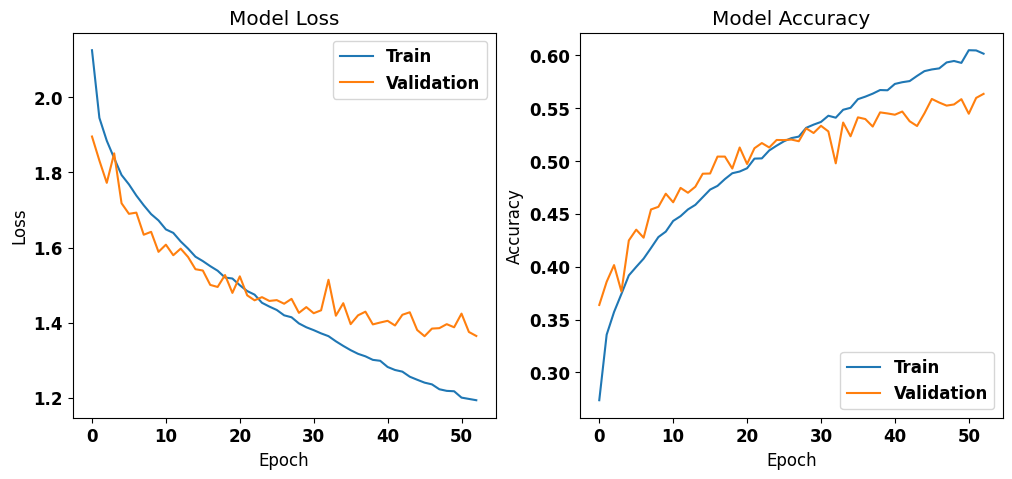

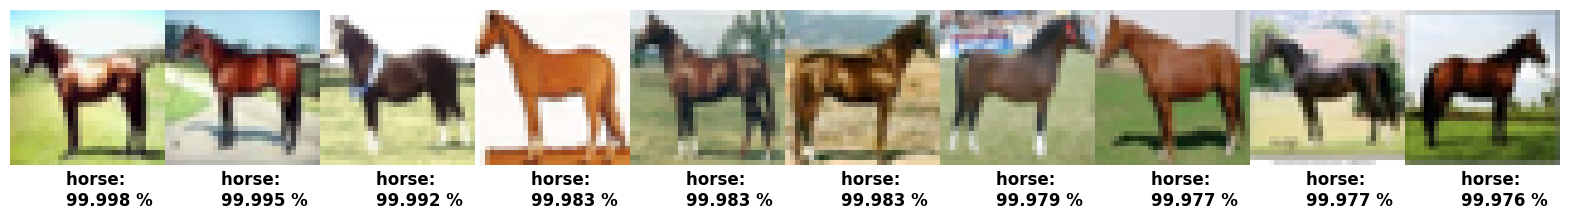

Best model accuracy: 55.35%
Best model loss: 1.3495


In [18]:
# Evaluating the best model 

df = pd.read_csv("results.csv")
best_model_data = df.sort_values(by="Val Accuracy", ascending=False).iloc[0]

print("--- WINNING PARAMETERS ---")
print(best_model_data)

print(f'Best accuracy: {best_model_data["Val Accuracy"]:.2f}%')
params = {
    'optimizer': best_model_data['Optimizer'],
    'learning_rate': best_model_data['Learning Rate'],
    'hidden_layers': best_model_data['Layers'],
    'hidden_units': np.array([np.int32(best_model_data['Initial neurons'] * best_model_data['Compression Factor']) for _ in range(best_model_data['Layers'])], dtype=np.int32).tolist(),
    'activations': best_model_data['Activation'],
    'epochs': epochs,
    'batch_size': best_model_data['Batch Size'],
    'dropout_rate': best_model_data['Dropout Rate'],
    'l2_reg': best_model_data['L2 Penalty'],
    'compression_factor': best_model_data['Compression Factor'],
}

print(f'Best parameters: {params}')

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async" # set GPU allocator
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Suppress TensorFlow logging (1 = INFO, 2 = WARNING, 3 = ERROR)
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0' # Disable oneDNN optimizations to reduce GPU memory fragmentation

import warnings
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR) # Disable some logging from Tensorflow

import tensorflow as tf
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test_encoded = tf.keras.utils.to_categorical(y_train, num_classes=10), tf.keras.utils.to_categorical(y_test, num_classes=10)

model = build_model(params)
model.summary()
compile_model(model, params)
history = train_model(model, params, verbose=1, x_train=x_train, y_train=y_train)
acc, loss = evaluate_model(model, verbose=1, x_test=x_test, y_test=y_test_encoded)
plot_training_history(model.history)

show_the_best_predictions(model, x_test, y_test)
print(f'Best model accuracy: {acc*100:.2f}%')
print(f'Best model loss: {loss:.4f}')
